# Analyse Exploratoire (EDA)
**Hackathon iSHEERO _ DataCamp 2026 — Bénin Insights Challenge**


Ce notebook réalise l'analyse exploratoire complète du dataset GDELT nettoyé  
couvrant les événements liés au **pays Bénin** sur l'année **2025**.

> **Important :** avoir exécuté `GDELT_Benin_Nettoyage.ipynb` pour disposer du fichier `data/GDELT_events_benin_2025_cleaned.csv`

##  Sommaire
1. [Imports et chargement](#1)
2. [Vue d'ensemble du dataset](#2)
3. [Analyse temporelle](#3)
4. [Analyse des types d'événements](#4)
5. [Analyse des acteurs](#5)
6. [Evenement vs acteurs pays etranger](#6)
7. [Analyse géographique](#7)
8. [Analyse du ton et de la stabilité (GoldsteinScale)](#8)
9. [Analyse des sources médiatiques](#9)
10. [Synthèse et observations clés](#10)


## 1. Imports et chargement <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

#  Style global 
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'figure.dpi':       130,
})

PALETTE = {
    'coop_verbal':     '#2E86AB',
    'coop_material':   '#5BC0BE',
    'conflict_verbal': '#F6AE2D',
    'conflict_material':'#F26419',
    'neutral':         '#8E8E93',
    'benin_green':     '#008751',
    'benin_yellow':    '#FCD116',
    'benin_red':       '#E8112D',
}

INPUT_FILE = "../data/GDELT_events_benin_2025_cleaned.csv"
print(" Imports OK")


 Imports OK


In [2]:
#  Chargement & préparation des colonnes de dates 
df = pd.read_csv(INPUT_FILE, low_memory=False)

df['date'] = pd.to_datetime(df['SQLDATE'], format='ISO8601')
df['month']      = df['date'].dt.to_period('M')
df['week']       = df['date'].dt.to_period('W')
df['month_dt']   = df['date'].dt.to_period('M').dt.to_timestamp('M')
df['month_str']  = df['date'].dt.strftime('%b %Y')

# Mapping QuadClass
QC_MAP   = {1:'Verbal Cooperation', 2:'Material Cooperation',
            3:'Verbal Conflict',    4:'Material Conflict'}
QC_COLORS= {1: PALETTE['coop_verbal'],  2: PALETTE['coop_material'],
             3: PALETTE['conflict_verbal'], 4: PALETTE['conflict_material']}
df['QuadClass_label'] = df['QuadClass'].map(QC_MAP)

# Mapping EventRootCode
EVROOT_MAP = {
    1:'Make Public Statement', 2:'Appeal', 3:'Express Intent to Cooperate',
    4:'Consult', 5:'Engage in Diplomatic Cooperation',
    6:'Engage in Material Cooperation', 7:'Provide Aid',
    8:'Yield', 9:'Investigate', 10:'Demand', 11:'Disapprove',
    12:'Reject', 13:'Threaten', 14:'Protest', 15:'Exhibit Military Posture',
    16:'Reduce Relations', 17:'Coerce', 18:'Assault', 19:'Fight',
    20:'Unconventional Mass Violence'
}
df['EventRoot_label'] = df['EventRootCode'].map(EVROOT_MAP)

print(f" Dataset chargé : {len(df):,} événements")
print(f"   Période  : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"   Colonnes : {df.shape[1]}")


 Dataset chargé : 23,967 événements
   Période  : 2025-01-01 → 2025-12-31
   Colonnes : 43


In [3]:


# Extraction du domaine source depuis l'URL
df['domain'] = df['SOURCEURL'].str.extract(r'https?://(?:www\.)?([^/]+)')

print(f"Shape brut : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print()
print("Aperçu des colonnes disponibles :")
print(df.dtypes.to_string())

Shape brut : 23,967 lignes × 44 colonnes

Aperçu des colonnes disponibles :
Unnamed: 0                         int64
GLOBALEVENTID                      int64
SQLDATE                              str
MonthYear                            str
Actor1Name                           str
Actor1CountryCode                    str
Actor1CountryLabel                   str
Actor1Type1Code                      str
Actor1Type1Label                     str
Actor2Name                           str
Actor2CountryCode                    str
Actor2CountryLabel                   str
Actor2Type1Code                      str
Actor2Type1Label                     str
IsRootEvent                        int64
EventCode                          int64
EventLabel                           str
EventBaseCode                      int64
EventBaseLabel                       str
EventRootCode                      int64
EventRootLabel                       str
QuadClass                          int64
QuadClassLabel        

## 2. Vue d'ensemble du dataset <a id='2'></a>

In [4]:
#  Métriques clés 
print("=" * 55)
print("  MÉTRIQUES CLÉS — GDELT BÉNIN 2025")
print("=" * 55)
print(f"  Événements total          : {len(df):>7,}")
print(f"  Sources uniques           : {df['domain'].nunique():>7,}")
print(f"  Acteurs 1 uniques         : {df['Actor1Name'].nunique():>7,}")
print(f"  Acteurs 2 uniques         : {df['Actor2Name'].nunique():>7,}")
print(f"  Lieux uniques             : {df['ActionGeo_FullName'].nunique():>7,}")
print(f"  GoldsteinScale moyen      : {df['GoldsteinScale'].mean():>7.2f}")
print(f"  AvgTone moyen             : {df['AvgTone'].mean():>7.2f}")
print(f"  % Coopération (QuadClass 1+2) : {100*(df['QuadClass'].isin([1,2])).mean():.1f}%")
print(f"  % Conflit     (QuadClass 3+4) : {100*(df['QuadClass'].isin([3,4])).mean():.1f}%")
print("=" * 55)


  MÉTRIQUES CLÉS — GDELT BÉNIN 2025
  Événements total          :  23,967
  Sources uniques           :   1,460
  Acteurs 1 uniques         :     820
  Acteurs 2 uniques         :     723
  Lieux uniques             :     705
  GoldsteinScale moyen      :    0.83
  AvgTone moyen             :   -1.23
  % Coopération (QuadClass 1+2) : 75.3%
  % Conflit     (QuadClass 3+4) : 24.7%


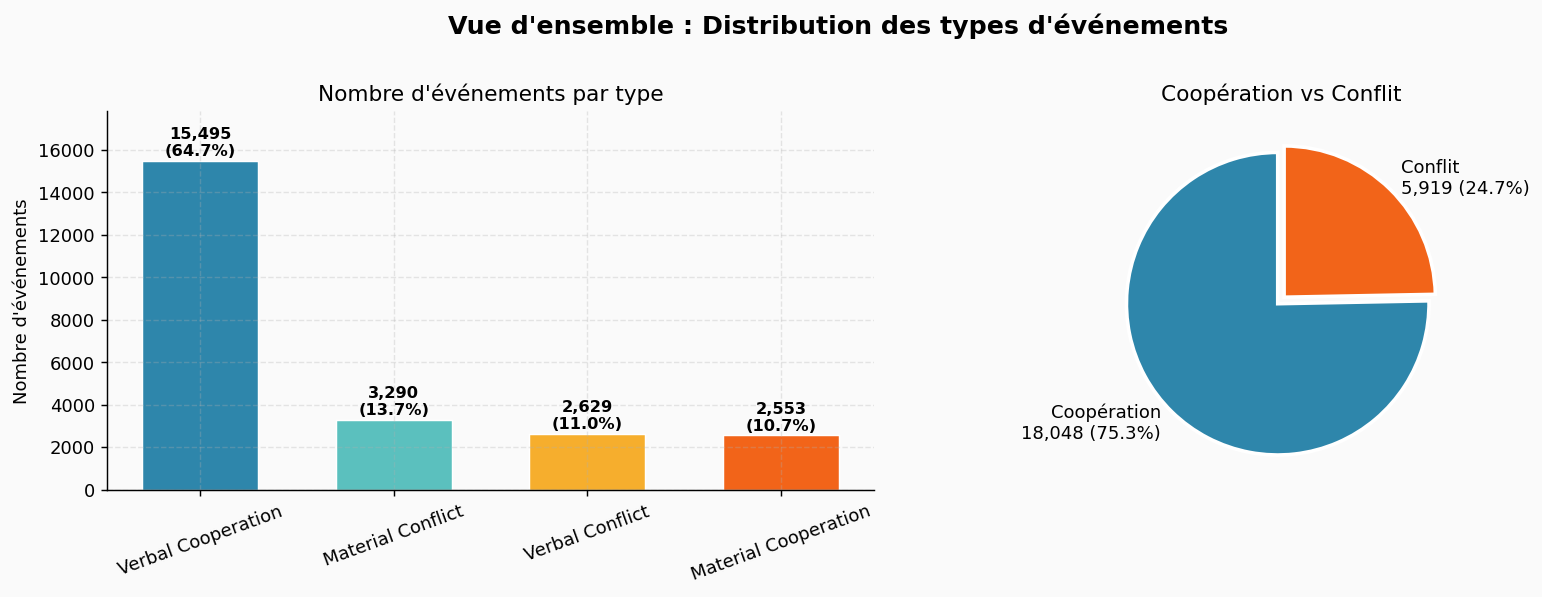

Figure sauvegardée : fig_overview.png


In [5]:
#  Distribution QuadClass 
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Vue d'ensemble : Distribution des types d'événements", 
             fontsize=14, fontweight='bold', y=1.01)

qc_counts = df['QuadClassLabel'].value_counts()
colors_bar = [QC_COLORS[k] for k in sorted(QC_MAP.keys())]

# Barres
bars = axes[0].bar(qc_counts.index, qc_counts.values,
                   color=[QC_COLORS[k] for k,v in QC_MAP.items() if v in qc_counts.index],
                   edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars, qc_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{val:,}\n({100*val/len(df):.1f}%)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Nombre d\'événements par type')
axes[0].set_ylabel('Nombre d\'événements')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylim(0, qc_counts.max() * 1.15)

# Camembert coopération vs conflit
coop    = df['QuadClass'].isin([1,2]).sum()
conflict= df['QuadClass'].isin([3,4]).sum()
axes[1].pie([coop, conflict],
            labels=[f'Coopération\n{coop:,} ({100*coop/len(df):.1f}%)',
                    f'Conflit\n{conflict:,} ({100*conflict/len(df):.1f}%)'],
            colors=[PALETTE['coop_verbal'], PALETTE['conflict_material']],
            startangle=90, explode=(0.03, 0.03),
            wedgeprops={'edgecolor':'white','linewidth':2},
            textprops={'fontsize':10})
axes[1].set_title('Coopération vs Conflit')

plt.tight_layout()
plt.savefig('fig_overview.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_overview.png")


## 3. Analyse temporelle <a id='3'></a>

On observe l'évolution mensuelle du **volume d'événements**, du **GoldsteinScale** (stabilité géopolitique)  
et du **ton moyen** des articles, ainsi que la répartition coopération/conflit dans le temps.


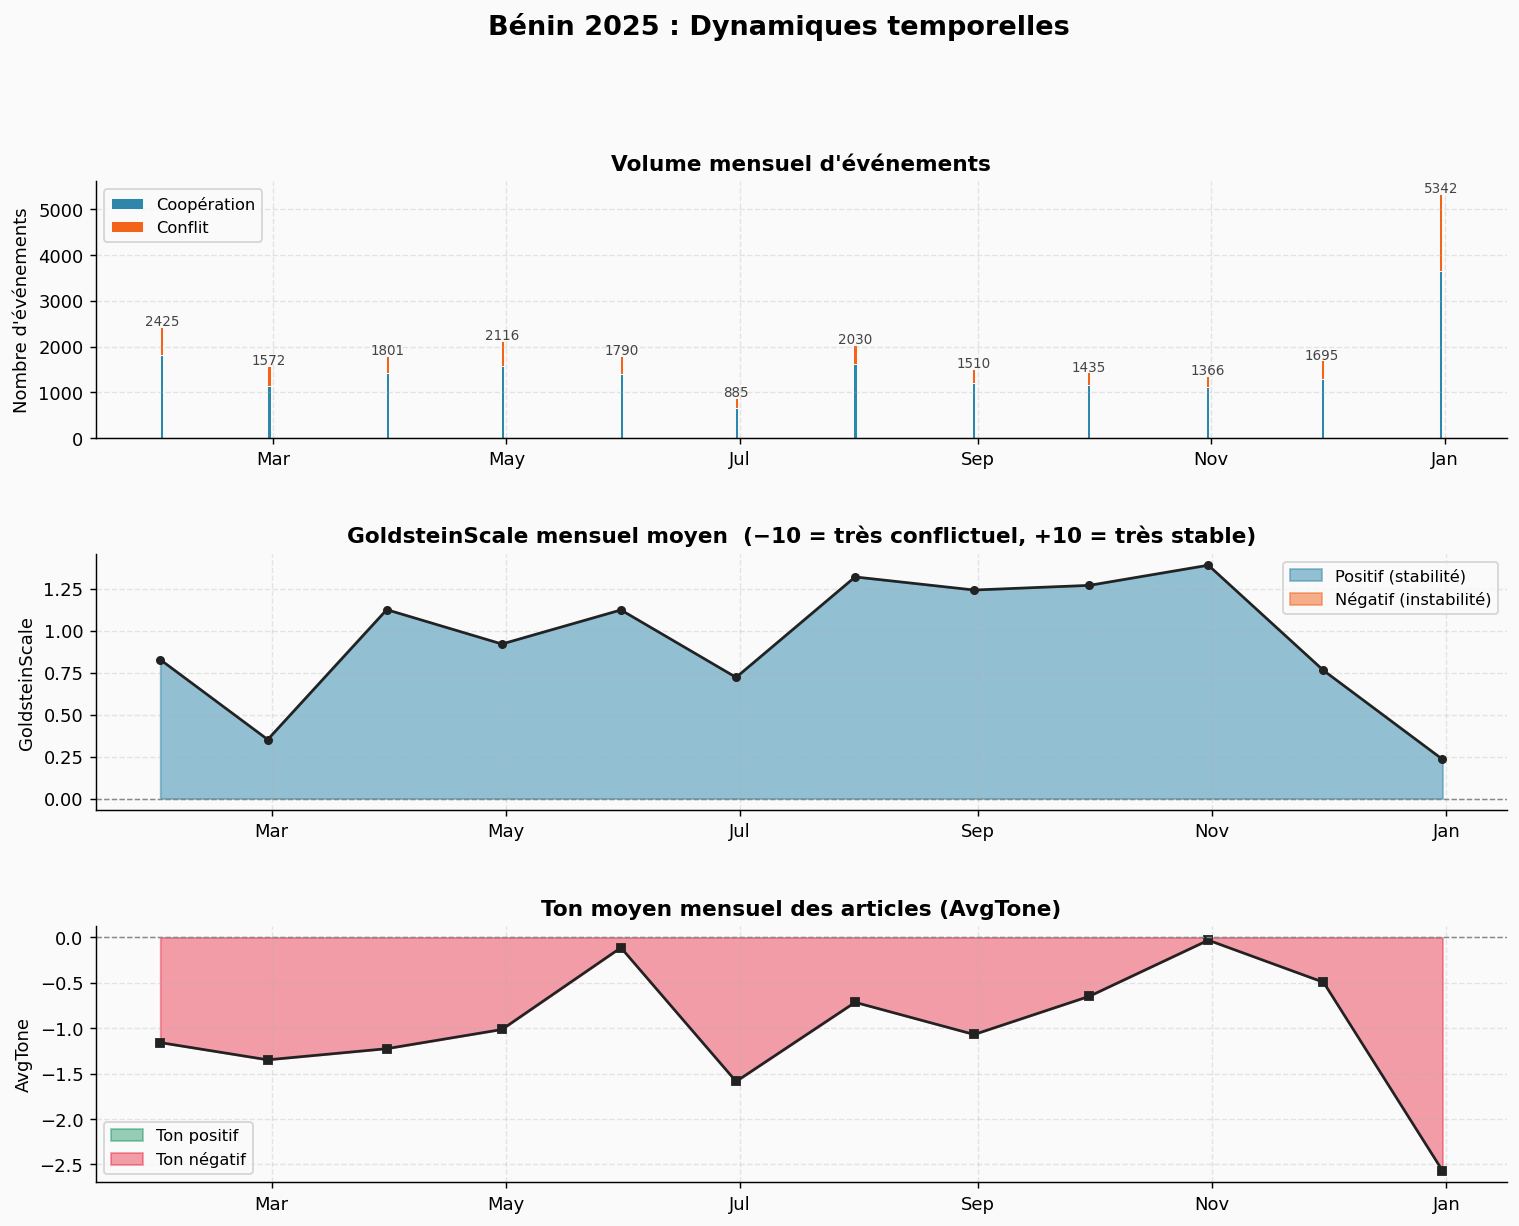

Figure sauvegardée : fig_temporal.png


In [6]:
#  Volume mensuel + GoldsteinScale + AvgTone 
monthly = df.groupby('month_dt').agg(
    n_events    = ('GLOBALEVENTID', 'count'),
    goldstein   = ('GoldsteinScale', 'mean'),
    tone        = ('AvgTone', 'mean'),
    n_conflict  = ('QuadClass', lambda x: (x.isin([3,4])).sum()),
    n_coop      = ('QuadClass', lambda x: (x.isin([1,2])).sum()),
).reset_index()
monthly['pct_conflict'] = 100 * monthly['n_conflict'] / monthly['n_events']

fig = plt.figure(figsize=(14, 10))
gs  = GridSpec(3, 1, figure=fig, hspace=0.45)

# --- Subplot 1 : volume mensuel empilé coop/conflit ---
ax1 = fig.add_subplot(gs[0])
ax1.bar(monthly['month_dt'], monthly['n_coop'],
        label='Coopération', color=PALETTE['coop_verbal'],
        edgecolor='white', linewidth=0.5)
ax1.bar(monthly['month_dt'], monthly['n_conflict'],
        bottom=monthly['n_coop'],
        label='Conflit', color=PALETTE['conflict_material'],
        edgecolor='white', linewidth=0.5)
ax1.set_title('Volume mensuel d\'événements', fontweight='bold')
ax1.set_ylabel('Nombre d\'événements')
ax1.legend(loc='upper left', fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
for _, row in monthly.iterrows():
    ax1.text(row['month_dt'], row['n_events'] + 30,
             str(int(row['n_events'])), ha='center', fontsize=7.5, color='#444')

# --- Subplot 2 : GoldsteinScale ---
ax2 = fig.add_subplot(gs[1])
ax2.fill_between(monthly['month_dt'], 0, monthly['goldstein'],
                 where=monthly['goldstein'] >= 0,
                 color=PALETTE['coop_verbal'], alpha=0.5, label='Positif (stabilité)')
ax2.fill_between(monthly['month_dt'], 0, monthly['goldstein'],
                 where=monthly['goldstein'] < 0,
                 color=PALETTE['conflict_material'], alpha=0.5, label='Négatif (instabilité)')
ax2.plot(monthly['month_dt'], monthly['goldstein'],
         color='#222', linewidth=1.5, marker='o', markersize=4)
ax2.axhline(0, color='#888', linewidth=0.8, linestyle='--')
ax2.set_title('GoldsteinScale mensuel moyen  (−10 = très conflictuel, +10 = très stable)',
              fontweight='bold')
ax2.set_ylabel('GoldsteinScale')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# --- Subplot 3 : AvgTone ---
ax3 = fig.add_subplot(gs[2])
ax3.fill_between(monthly['month_dt'], 0, monthly['tone'],
                 where=monthly['tone'] >= 0,
                 color=PALETTE['benin_green'], alpha=0.4, label='Ton positif')
ax3.fill_between(monthly['month_dt'], 0, monthly['tone'],
                 where=monthly['tone'] < 0,
                 color=PALETTE['benin_red'], alpha=0.4, label='Ton négatif')
ax3.plot(monthly['month_dt'], monthly['tone'],
         color='#222', linewidth=1.5, marker='s', markersize=4)
ax3.axhline(0, color='#888', linewidth=0.8, linestyle='--')
ax3.set_title('Ton moyen mensuel des articles (AvgTone)', fontweight='bold')
ax3.set_ylabel('AvgTone')
ax3.legend(fontsize=9)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

fig.suptitle('Bénin 2025 : Dynamiques temporelles', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('fig_temporal.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_temporal.png")


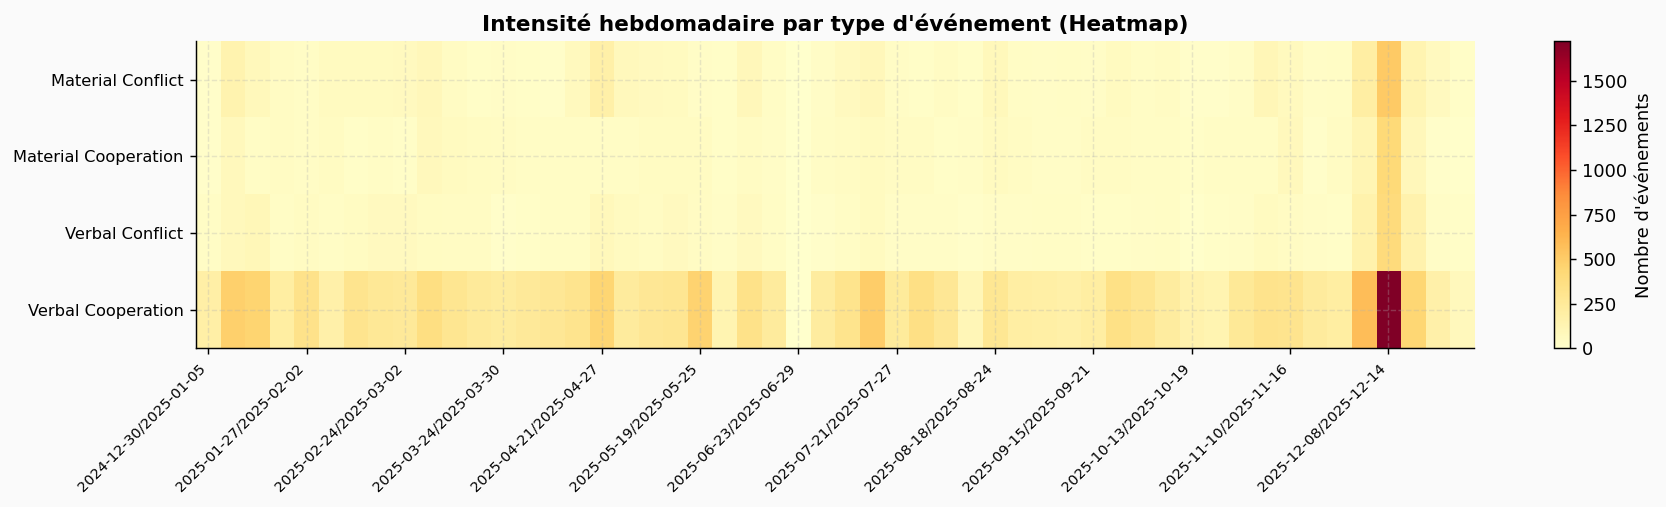

Figure sauvegardée : fig_heatmap_week.png


In [7]:
#  Heatmap semaine × QuadClass 
weekly_qc = df.groupby(['week', 'QuadClass_label']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(weekly_qc.T.values, aspect='auto',
               cmap='YlOrRd', interpolation='nearest')
ax.set_yticks(range(len(weekly_qc.columns)))
ax.set_yticklabels(weekly_qc.columns, fontsize=9)
ax.set_xticks(range(0, len(weekly_qc), 4))
ax.set_xticklabels([str(w) for w in weekly_qc.index[::4]], rotation=45, ha='right', fontsize=8)
ax.set_title('Intensité hebdomadaire par type d\'événement (Heatmap)', 
             fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax, label='Nombre d\'événements')
plt.tight_layout()
plt.savefig('fig_heatmap_week.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_heatmap_week.png")


## 4. Analyse des types d'événements <a id='4'></a>

GDELT code les événements selon la **CAMEO taxonomy** (Conflict and Mediation Event Observations).  
L'`EventRootCode` donne la catégorie principale (19 types).


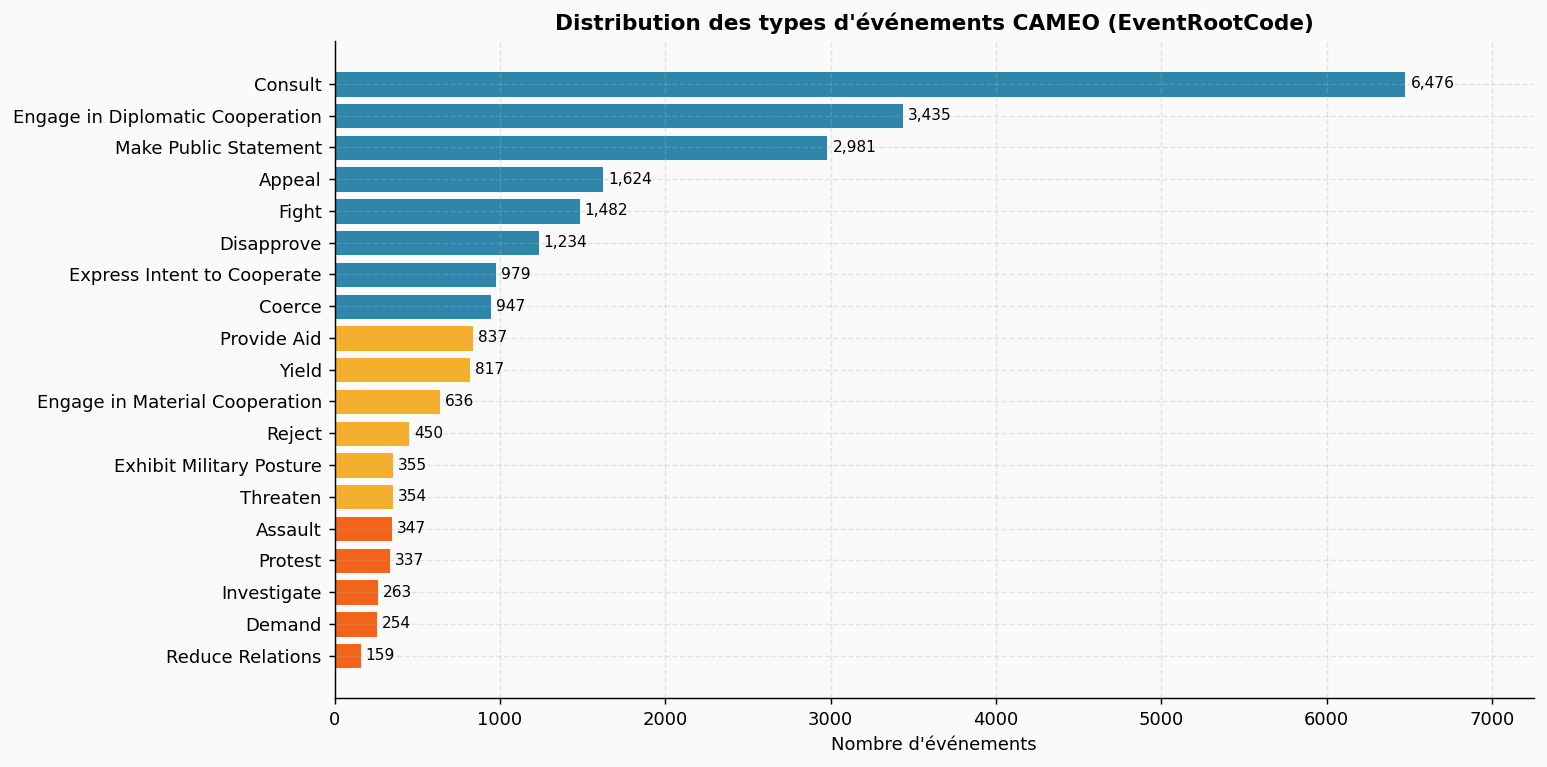

Figure sauvegardée : fig_eventroot.png


In [8]:
#  Top EventRootCode 
ev_counts = df['EventRoot_label'].value_counts()
colors_ev  = [PALETTE['coop_verbal'] if i < 8
              else PALETTE['conflict_verbal'] if i < 14
              else PALETTE['conflict_material']
              for i in range(len(ev_counts))]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(ev_counts.index[::-1], ev_counts.values[::-1],
               color=colors_ev[::-1], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, ev_counts.values[::-1]):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8.5)
ax.set_title('Distribution des types d\'événements CAMEO (EventRootCode)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Nombre d\'événements')
ax.set_xlim(0, ev_counts.max() * 1.12)
plt.tight_layout()
plt.savefig('fig_eventroot.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_eventroot.png")


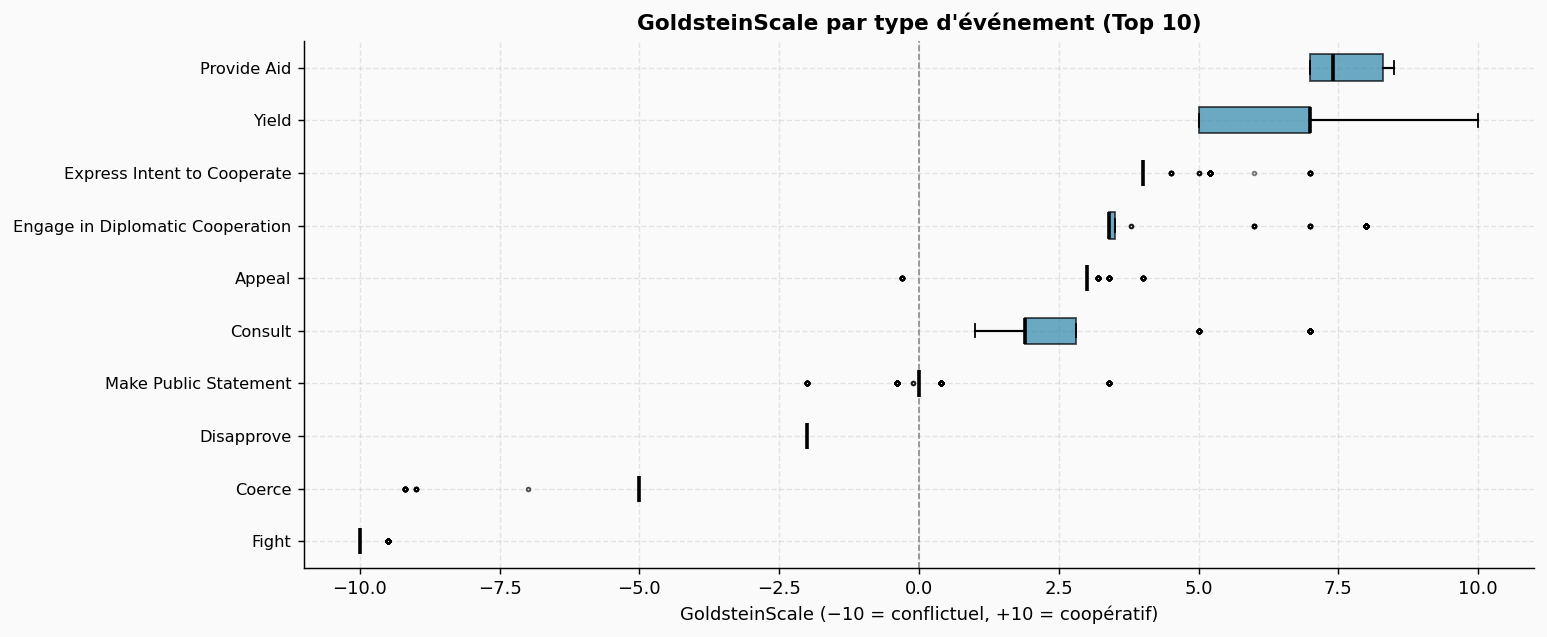

Figure sauvegardée : fig_goldstein_event.png


In [9]:
#  GoldsteinScale par EventRootCode (boxplot synthétique) 
top10_events = df['EventRoot_label'].value_counts().head(10).index.tolist()
df_top = df[df['EventRoot_label'].isin(top10_events)].copy()
order  = df_top.groupby('EventRoot_label')['GoldsteinScale'].median().sort_values().index

fig, ax = plt.subplots(figsize=(12, 5))
data_plot = [df_top[df_top['EventRoot_label'] == ev]['GoldsteinScale'].values for ev in order]
bp = ax.boxplot(data_plot, vert=False, patch_artist=True,
                medianprops={'color':'black','linewidth':2},
                whiskerprops={'linewidth':1.2},
                flierprops={'marker':'o','markersize':2,'alpha':0.3})

colors_bp = [PALETTE['conflict_material'] if m < 0 else PALETTE['coop_verbal']
             for m in [df_top[df_top['EventRoot_label']==ev]['GoldsteinScale'].median() for ev in order]]
for patch, col in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)

ax.set_yticks(range(1, len(order)+1))
ax.set_yticklabels(order, fontsize=9)
ax.axvline(0, color='#888', linestyle='--', linewidth=0.9)
ax.set_title('GoldsteinScale par type d\'événement (Top 10)', fontweight='bold')
ax.set_xlabel('GoldsteinScale (−10 = conflictuel, +10 = coopératif)')
plt.tight_layout()
plt.savefig('fig_goldstein_event.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_goldstein_event.png")


## 5. Analyse des acteurs <a id='5'></a>

Qui interagit avec le Bénin ? Qui initie les événements ? Quelles sont les paires d'acteurs dominantes ?


In [10]:
mapping_pays = {
    "BEN": "Bénin", "NGA": "Nigéria", "AFR": "Afrique", "FRA": "France",
    "WAF": "Afrique de l'Ouest", "NER": "Niger", "GHA": "Ghana", "USA": "États-Unis",
    "TGO": "Togo", "BFA": "Burkina Faso", "GBR": "Royaume-Uni", "CHN": "Chine",
    "CIV": "Côte d'Ivoire", "SEN": "Sénégal", "NLD": "Pays-Bas"
}
# ── Top Actor1 et Actor2 avec noms complets 
# On récupère le top 15, puis on renomme l'index avec le dictionnaire
top_a1 = df['Actor1CountryCode'].value_counts().head(15)
top_a1.index = [mapping_pays.get(x, x) for x in top_a1.index]

top_a2 = df['Actor2CountryCode'].value_counts().head(15)
top_a2.index = [mapping_pays.get(x, x) for x in top_a2.index]

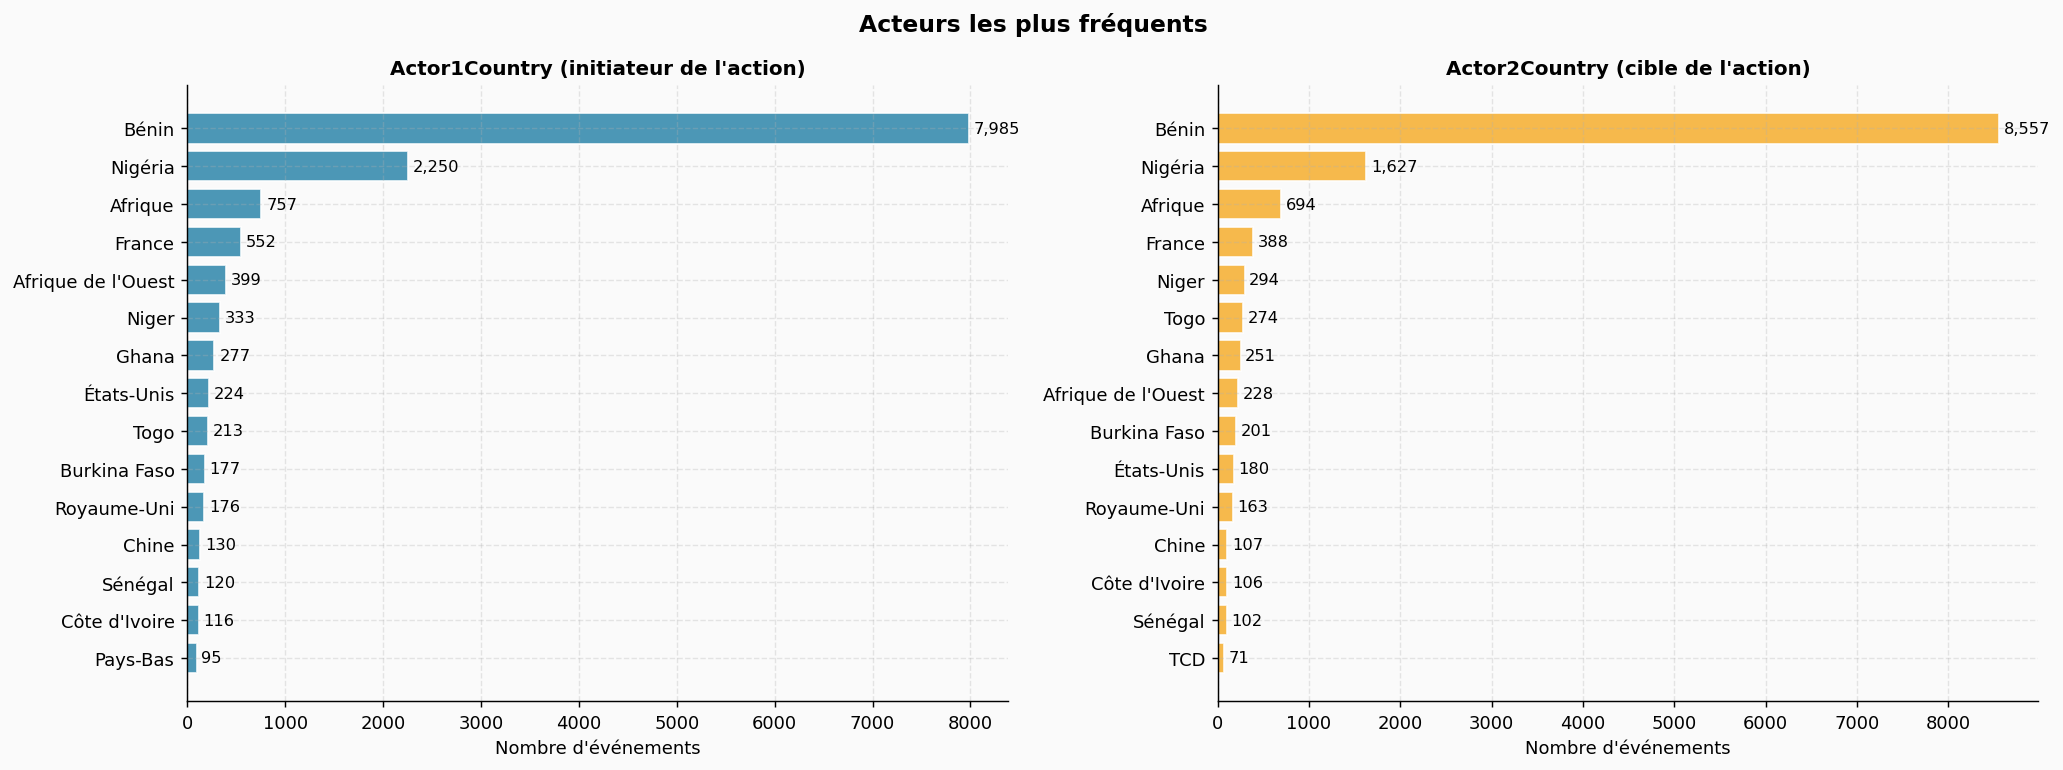

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Légère augmentation de la largeur pour les noms longs
fig.suptitle('Acteurs les plus fréquents', fontsize=13, fontweight='bold')

for ax, data, title, color in [
    (axes[0], top_a1, "Actor1Country (initiateur de l'action)", PALETTE['coop_verbal']),
    (axes[1], top_a2, "Actor2Country (cible de l'action)",      PALETTE['conflict_verbal'])
]:
    # Inversion de l'ordre pour avoir le plus grand en haut
    names = data.index[::-1]
    values = data.values[::-1]
    
    bars = ax.barh(names, values, color=color, alpha=0.85, edgecolor='white')
    
    for bar, val in zip(bars, values):
        ax.text(val + 50, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)
                
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel("Nombre d'événements")
    ax.grid(axis='x', linestyle='--', alpha=0.3) # Optionnel : aide à la lecture

plt.tight_layout()
plt.savefig('fig_actors_complet.png', bbox_inches='tight', dpi=130)
plt.show()

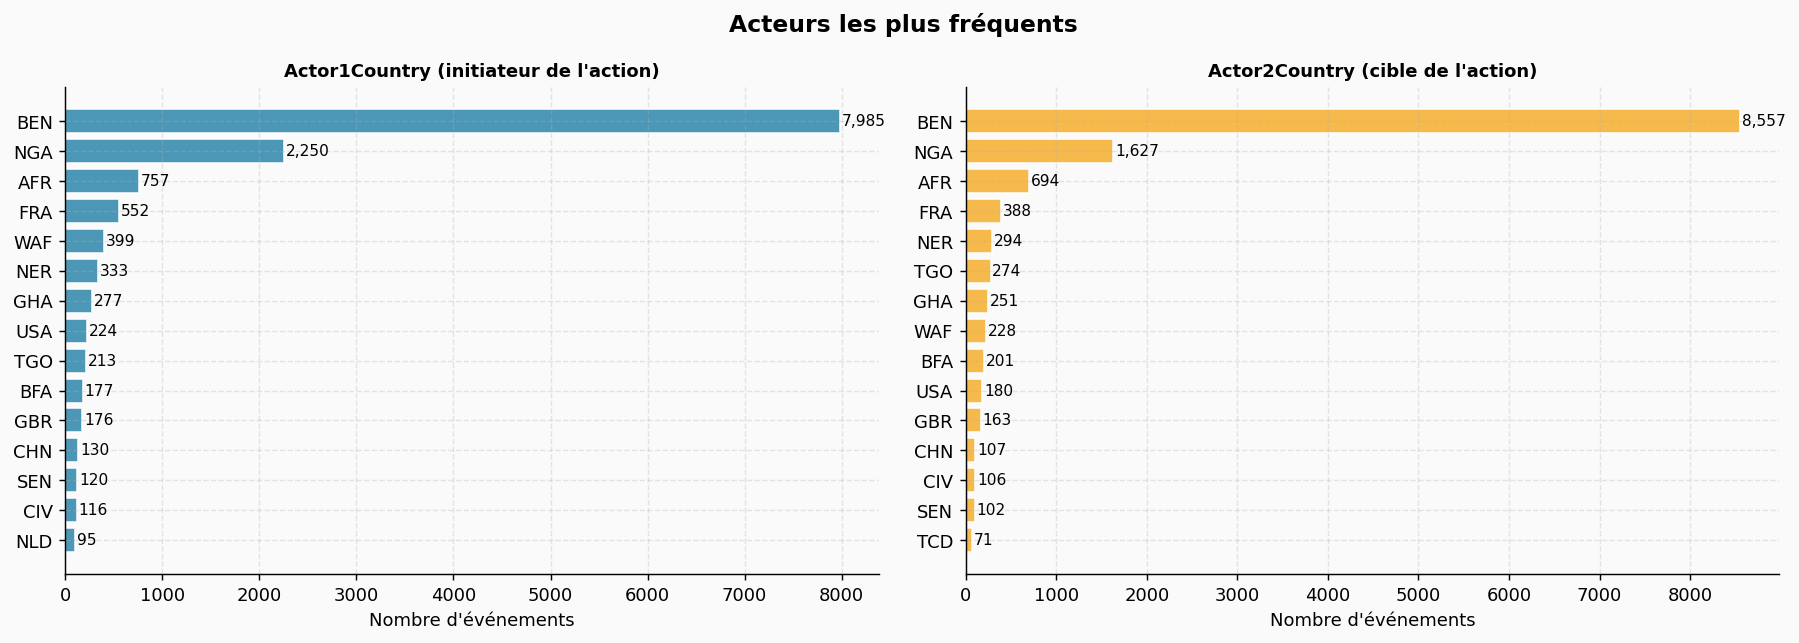

Figure sauvegardée : fig_actors.png


In [12]:
# Top Actor1 et Actor2 
top_a1 = df['Actor1CountryCode'].value_counts().head(15)
top_a2 = df['Actor2CountryCode'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Acteurs les plus fréquents', fontsize=13, fontweight='bold')

for ax, data, title, color in [
    (axes[0], top_a1, 'Actor1Country (initiateur de l\'action)', PALETTE['coop_verbal']),
    (axes[1], top_a2, 'Actor2Country (cible de l\'action)',      PALETTE['conflict_verbal'])
]:
    bars = ax.barh(data.index[::-1], data.values[::-1],
                   color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, data.values[::-1]):
        ax.text(val + 20, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8.5)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Nombre d\'événements')

plt.tight_layout()
plt.savefig('fig_actors.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_actors.png")


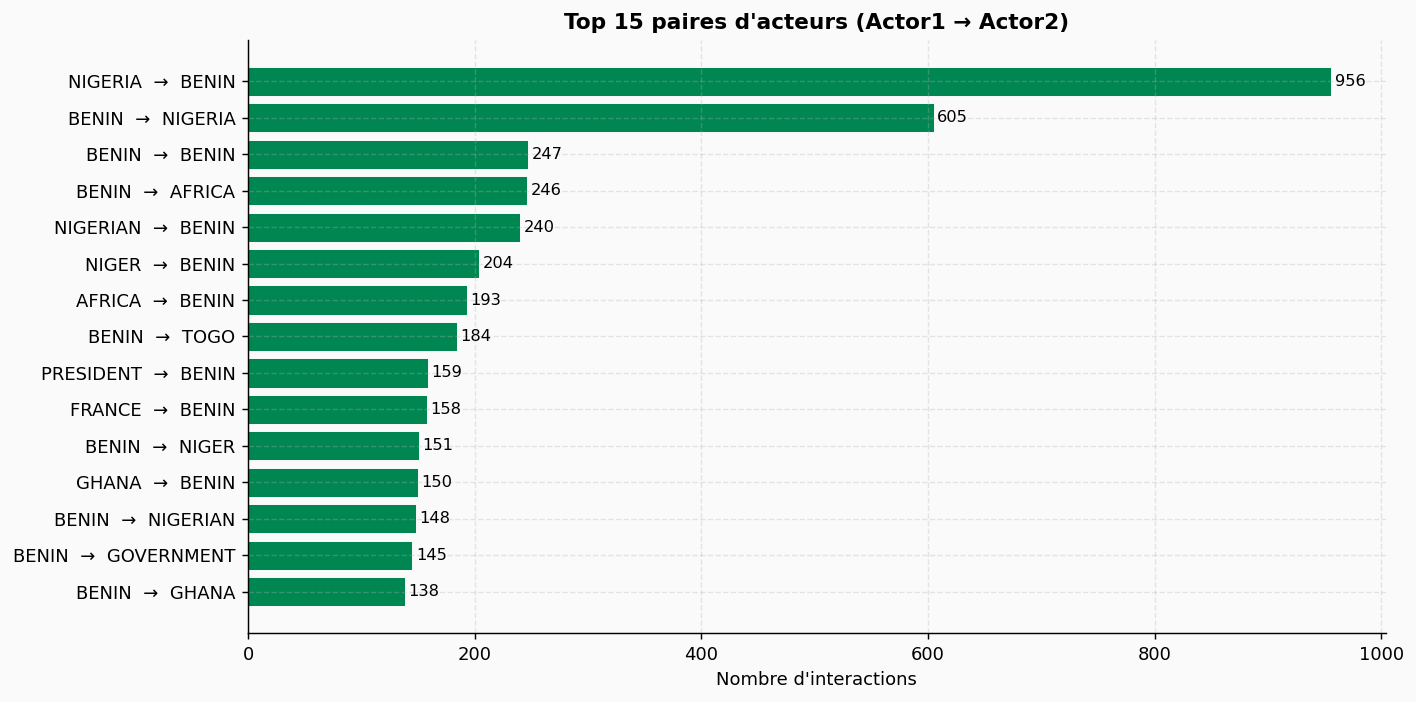

Figure sauvegardée : fig_pairs.png


In [13]:
# Top paires Actor1 → Actor2 
pairs = (df[df['Actor2Name'].notna()]
         .groupby(['Actor1Name','Actor2Name'])
         .size()
         .reset_index(name='count')
         .sort_values('count', ascending=False)
         .head(15))

pairs['label'] = pairs['Actor1Name'] + '  →  ' + pairs['Actor2Name']

fig, ax = plt.subplots(figsize=(11, 5.5))
colors_pairs = [PALETTE['benin_green'] if 'BENIN' in r['Actor1Name'] or 'BENIN' in r['Actor2Name']
                else PALETTE['neutral']
                for _, r in pairs.iterrows()]
bars = ax.barh(pairs['label'][::-1], pairs['count'][::-1],
               color=colors_pairs[::-1], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, pairs['count'][::-1]):
    ax.text(val + 3, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=9)
ax.set_title('Top 15 paires d\'acteurs (Actor1 → Actor2)', fontweight='bold', fontsize=12)
ax.set_xlabel('Nombre d\'interactions')
plt.tight_layout()
plt.savefig('fig_pairs.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_pairs.png")


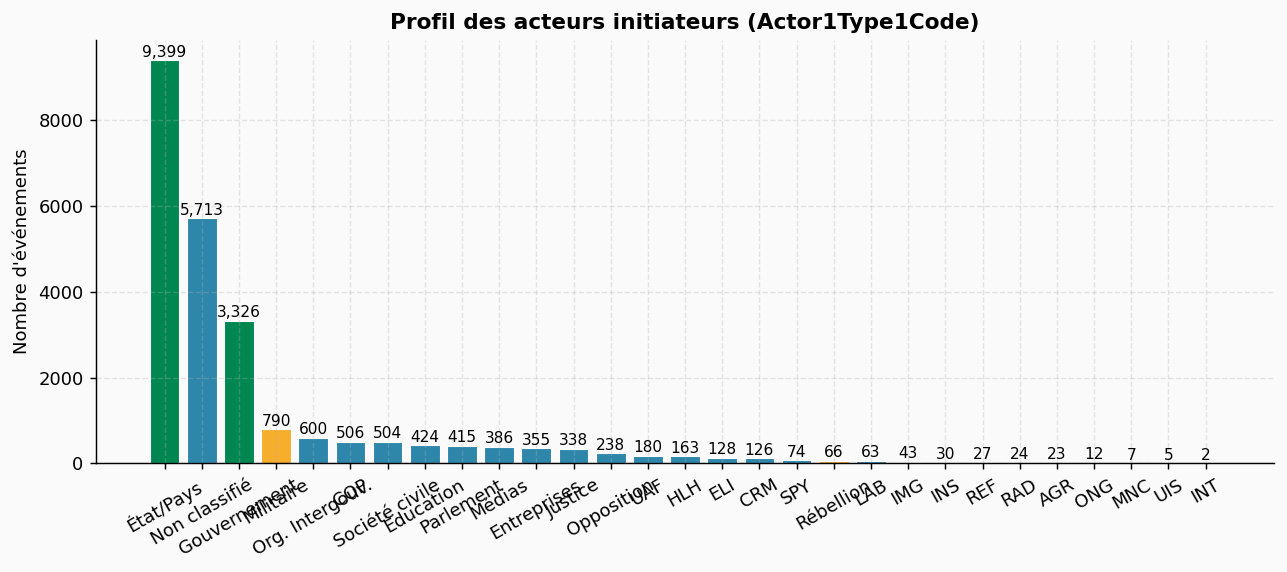

Figure sauvegardée : fig_actor_types.png


In [14]:
# Type d'acteur (Actor1Type1Code_filled) 
type_map = {
    'GOV':'Gouvernement', 'MIL':'Militaire', 'CVL':'Société civile',
    'MED':'Médias', 'EDU':'Éducation', 'BUS':'Entreprises',
    'STATE':'État/Pays', 'UNKNOWN':'Non classifié', 'OPP':'Opposition',
    'IGO':'Org. Intergouv.', 'NGO':'ONG', 'REL':'Religieux',
    'JUD':'Justice', 'LEG':'Parlement', 'REB':'Rébellion',
}
df['Actor1Type_fr'] = df['Actor1Type1Code_filled'].map(type_map).fillna(df['Actor1Type1Code_filled'])
type_counts = df['Actor1Type_fr'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(type_counts.index, type_counts.values,
              color=[PALETTE['benin_green'] if t in ['État/Pays','Gouvernement']
                     else PALETTE['conflict_verbal'] if t in ['Militaire','Rébellion']
                     else PALETTE['coop_verbal'] for t in type_counts.index],
              edgecolor='white', linewidth=0.6)
for bar, val in zip(bars, type_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{val:,}', ha='center', fontsize=8.5)
ax.set_title('Profil des acteurs initiateurs (Actor1Type1Code)', fontweight='bold')
ax.set_ylabel('Nombre d\'événements')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('fig_actor_types.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_actor_types.png")


## 6. Evenements vs acteurs pays etrangers

In [15]:
mapping_events = {
    "01": "Make Public Statement",
    "02": "Appeal",
    "03": "Express Intent to Cooperate",
    "04": "Consult",
    "05": "Engage in Diplomatic Cooperation",
    "06": "Engage in Material Cooperation",
    "07": "Provide Aid",
    "08": "Yield",
    "09": "Investigate",
    "10": "Demand",
    "11": "Disapprove",
    "12": "Reject",
    "13": "Threaten",
    "14": "Protest",
    "15": "Exhibit Military Posture",
    "16": "Reduce Relations",
    "17": "Coerce",
    "18": "Assault",
    "19": "Fight",
    "20": "Use Unconventional Mass Violence"
}

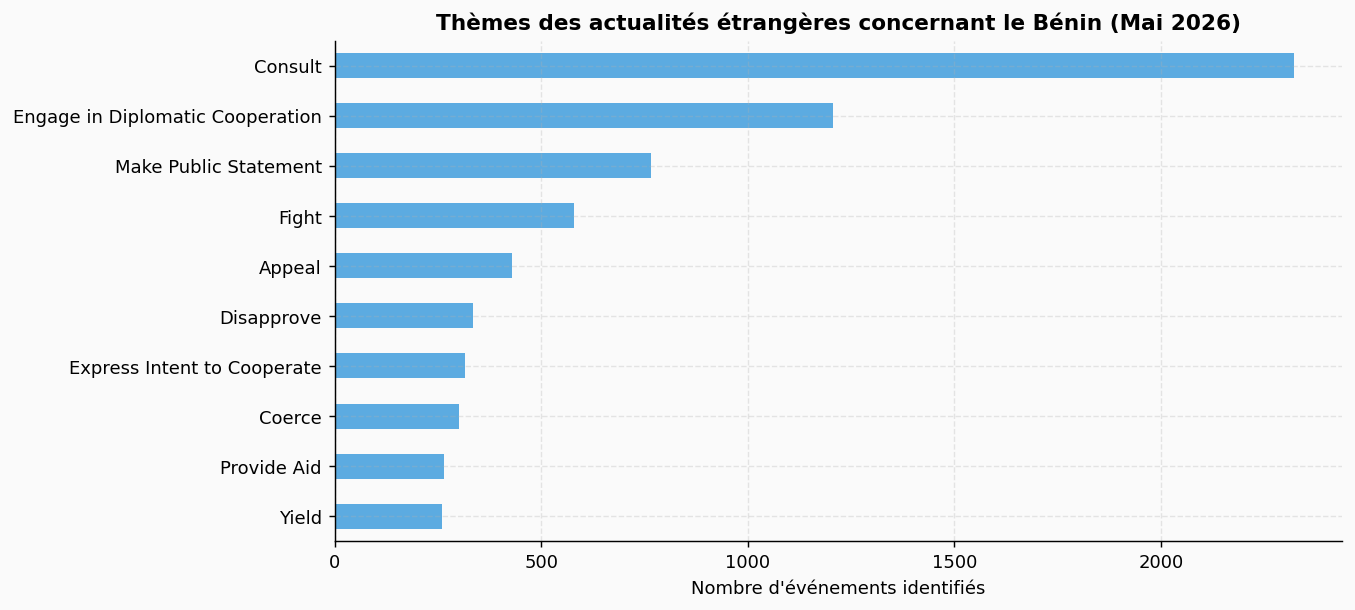

In [16]:
# On filtre les acteurs sur le Bénin provenant de l'étranger
foreign_on_benin = df[(df['Actor2CountryCode'] == 'BEN') & (df['Actor1CountryCode'] != 'BEN')]

# On récupère les types d'événements les plus fréquents
top_events = foreign_on_benin['EventRootCode'].value_counts().head(10)
top_events.index = [mapping_events.get(str(x).zfill(2), f"Code {x}") for x in top_events.index]

# Visualisation
plt.figure(figsize=(10, 5))
top_events.sort_values().plot(kind='barh', color='#3498db', alpha=0.8)
plt.title('Thèmes des actualités étrangères concernant le Bénin (Mai 2026)', fontweight='bold')
plt.xlabel("Nombre d'événements identifiés")
plt.show()

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. On filtre les données : Actor1 est étranger, Actor2 est le Bénin
df_foreign = df[(df['Actor2CountryCode'] == 'BEN') & (df['Actor1CountryCode'] != 'BEN')].copy()

# 2. On traduit les codes en noms complets pour la lisibilité
df_foreign['Pays_Source'] = df_foreign['Actor1CountryCode'].map(mapping_pays).fillna(df_foreign['Actor1CountryCode'])
df_foreign['Type_Evenement'] = df_foreign['EventRootCode'].astype(str).str.zfill(2).map(mapping_events)

# 3. On crée la table de croisement (Top 10 pays et Top 8 événements pour éviter de surcharger)
top_countries = df_foreign['Pays_Source'].value_counts().head(10).index
top_event_types = df_foreign['Type_Evenement'].value_counts().head(8).index

pivot_table = df_foreign[
    df_foreign['Pays_Source'].isin(top_countries) & 
    df_foreign['Type_Evenement'].isin(top_event_types)
].groupby(['Pays_Source', 'Type_Evenement']).size().unstack(fill_value=0)

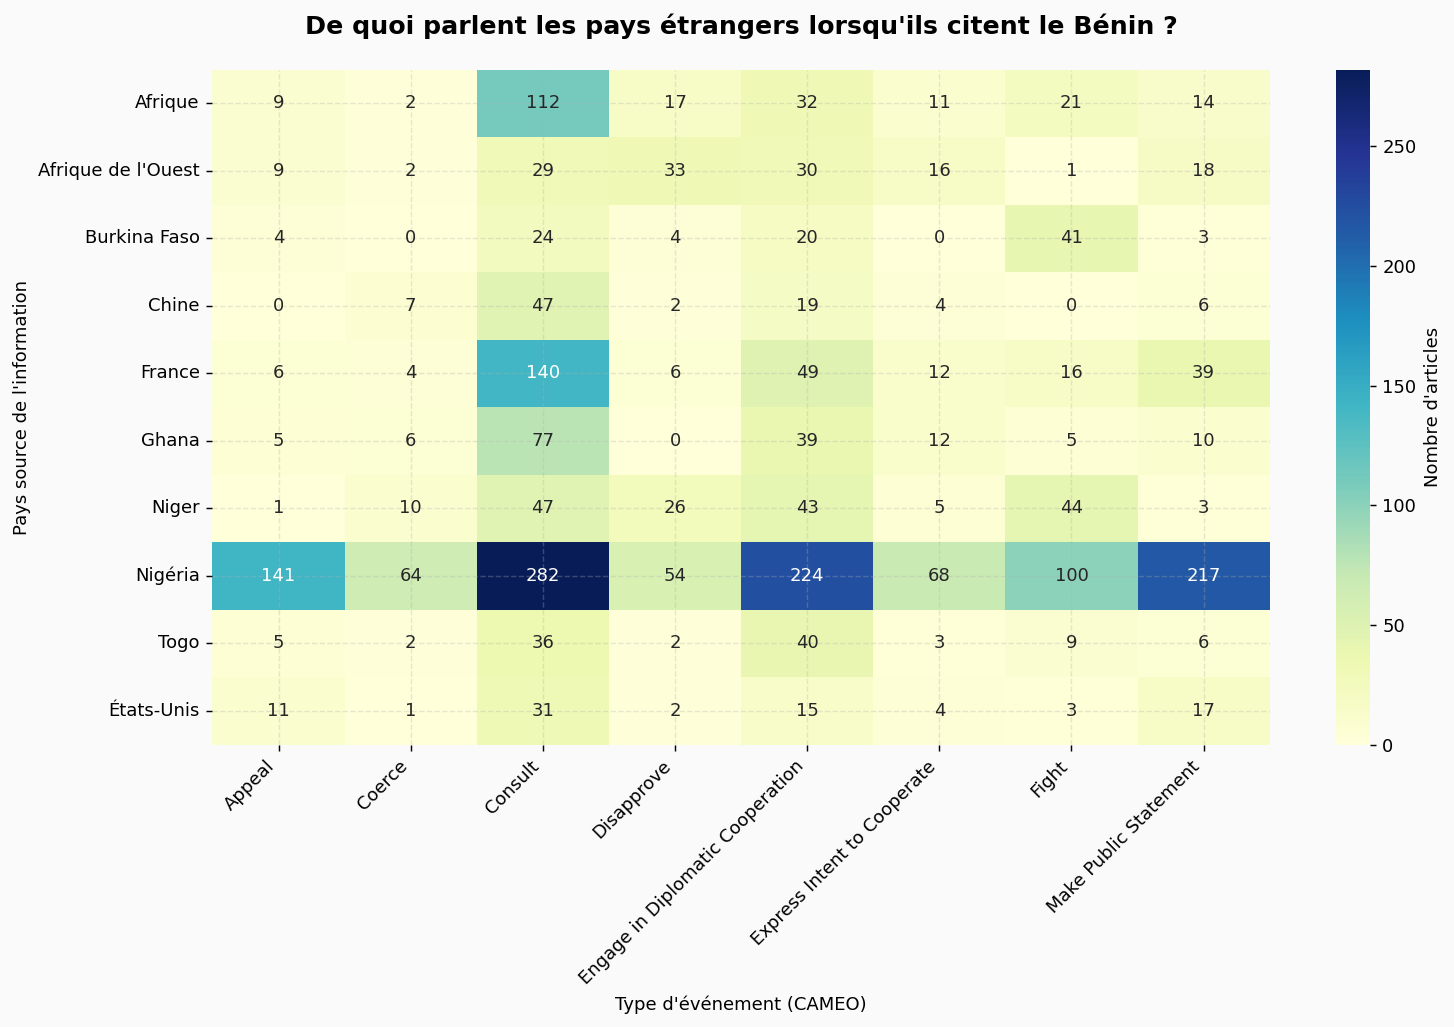

In [19]:
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': "Nombre d'articles"})

plt.title("De quoi parlent les pays étrangers lorsqu'ils citent le Bénin ?", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Type d'événement (CAMEO)", fontsize=10)
plt.ylabel("Pays source de l'information", fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('analyse_croisee_benin.png', dpi=130)
plt.show()

## 7. Analyse géographique <a id='6'></a>

Où se déroulent les événements ? Quelles régions du Bénin sont les plus actives ?


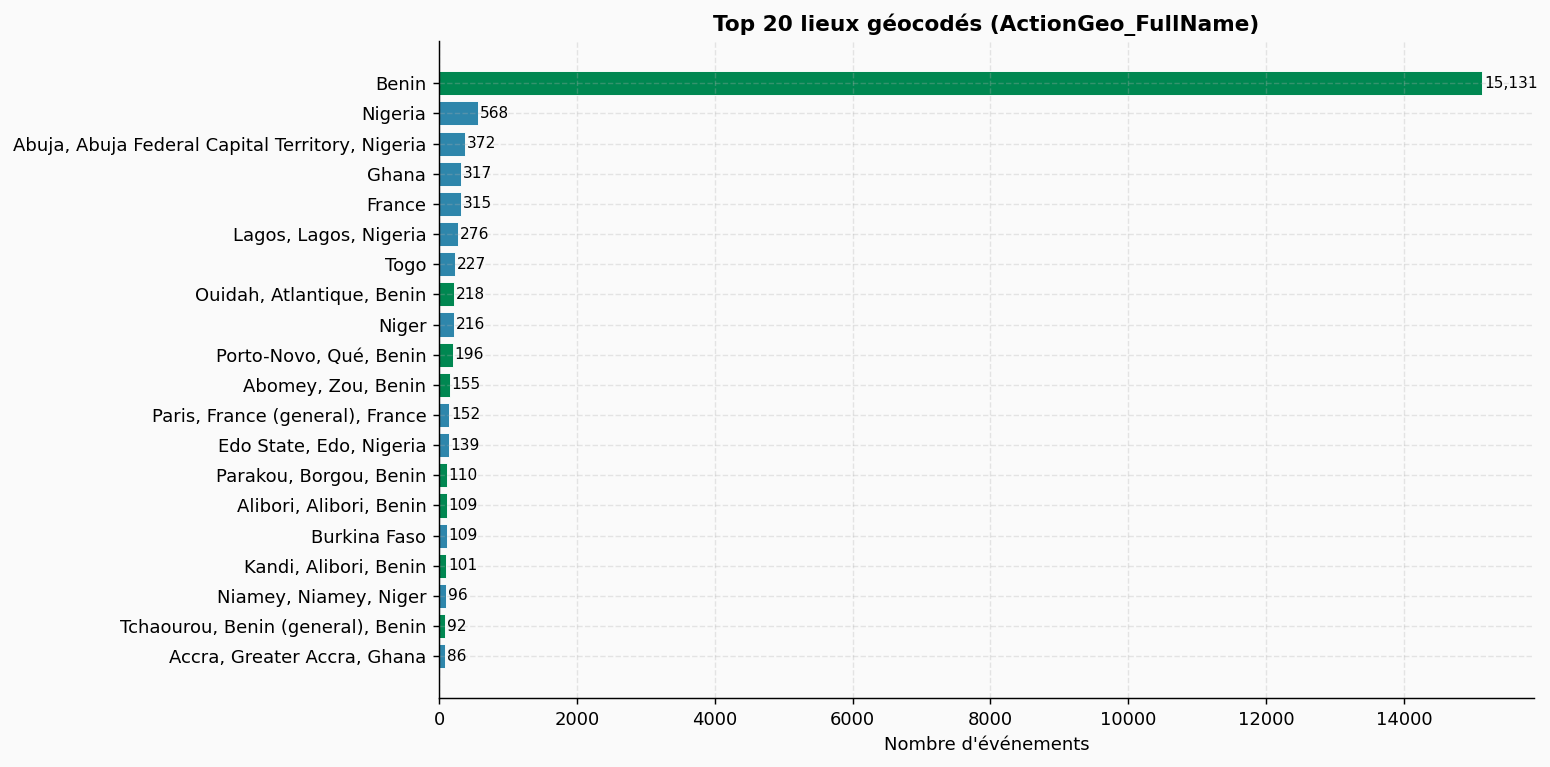

Figure sauvegardée : fig_geo_top.png


In [20]:
# Top lieux 
top_places = df['ActionGeo_FullName'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
colors_geo = [PALETTE['benin_green'] if 'Benin' in str(p) or p == 'Benin'
              else PALETTE['coop_verbal'] for p in top_places.index]
bars = ax.barh(top_places.index[::-1], top_places.values[::-1],
               color=colors_geo[::-1], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, top_places.values[::-1]):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8.5)
ax.set_title('Top 20 lieux géocodés (ActionGeo_FullName)', fontweight='bold', fontsize=12)
ax.set_xlabel('Nombre d\'événements')
plt.tight_layout()
plt.savefig('fig_geo_top.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_geo_top.png")


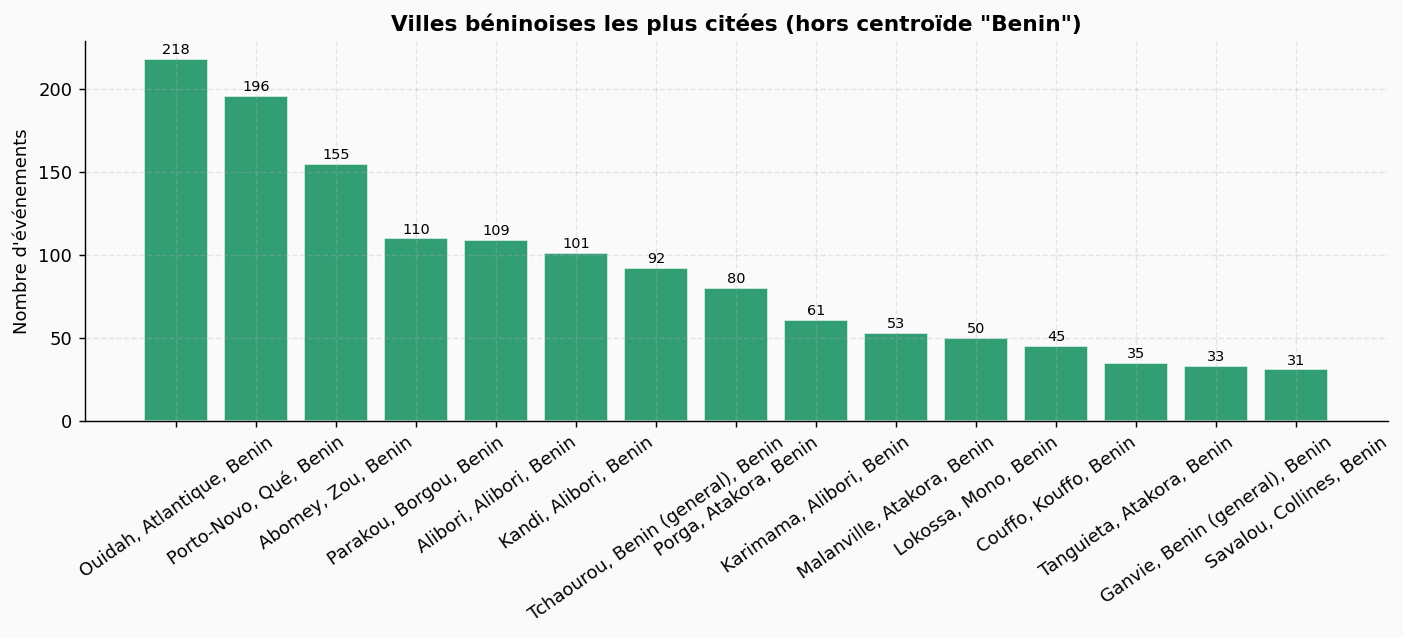

Figure sauvegardée : fig_benin_cities.png


In [21]:
#  Villes béninoises spécifiques 
benin_cities = df[
    (df['ActionGeo_CountryCode'] == 'BN') &
    (df['ActionGeo_FullName'] != 'Benin')
]['ActionGeo_FullName'].value_counts().head(15)

if len(benin_cities) > 0:
    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(benin_cities.index, benin_cities.values,
                  color=PALETTE['benin_green'], alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, benin_cities.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{val}', ha='center', fontsize=8)
    ax.set_title('Villes béninoises les plus citées (hors centroïde "Benin")',
                 fontweight='bold')
    ax.set_ylabel('Nombre d\'événements')
    ax.tick_params(axis='x', rotation=35)
    plt.tight_layout()
    plt.savefig('fig_benin_cities.png', bbox_inches='tight', dpi=130)
    plt.show()
    print("Figure sauvegardée : fig_benin_cities.png")
else:
    print("Pas assez de villes béninoises spécifiques dans ce dataset.")


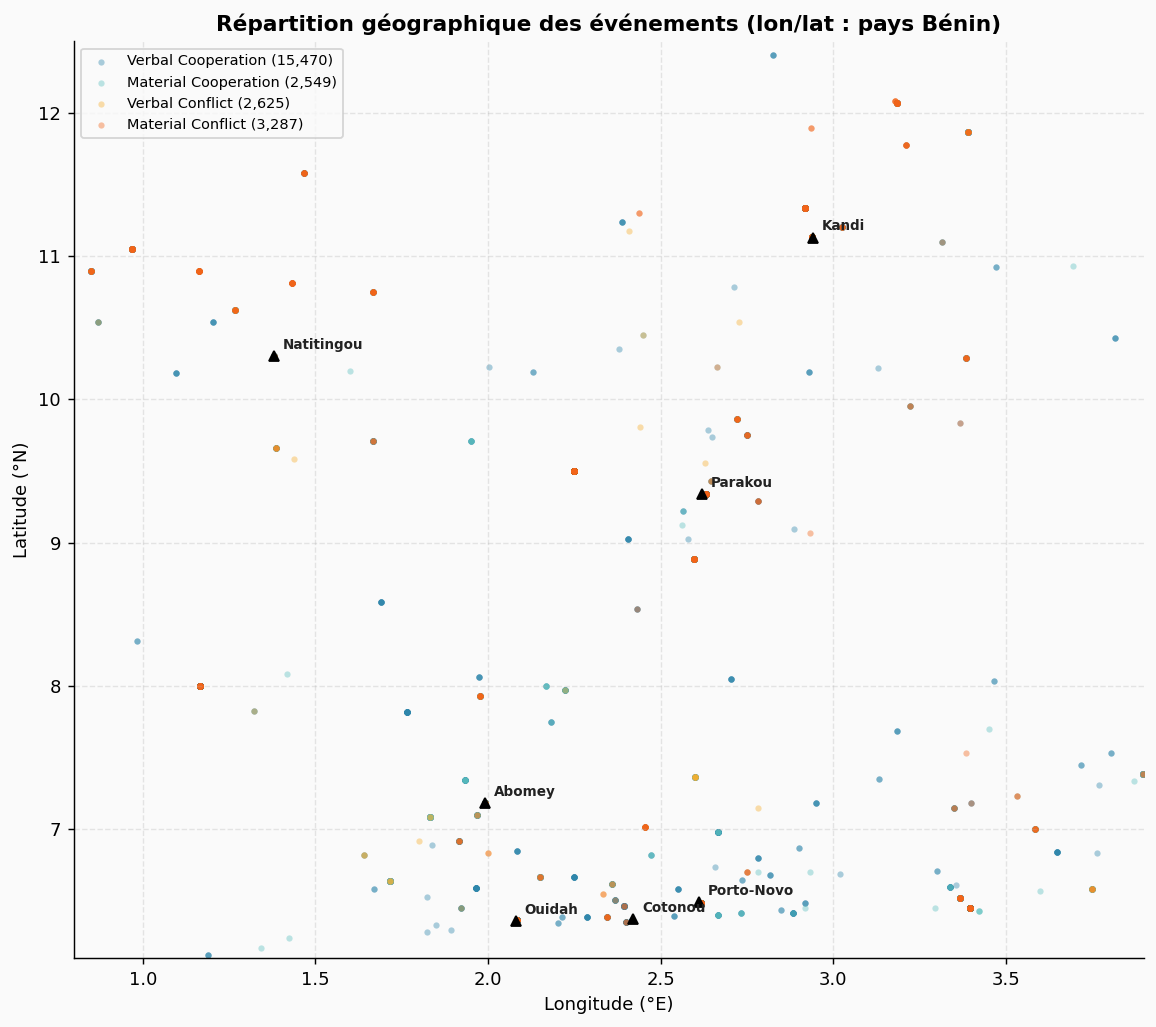

Figure sauvegardée : fig_geo_scatter.png


In [22]:
#  Scatter géographique des événements 
df_geo = df[df['ActionGeo_Lat'].notna() & df['ActionGeo_Long'].notna()].copy()

fig, ax = plt.subplots(figsize=(9, 8))

# Points colorés par QuadClass
for qc, label in QC_MAP.items():
    sub = df_geo[df_geo['QuadClass'] == qc]
    ax.scatter(sub['ActionGeo_Long'], sub['ActionGeo_Lat'],
               c=QC_COLORS[qc], label=f'{label} ({len(sub):,})',
               s=12, alpha=0.4, linewidths=0)

# Frontières approximatives du Bénin (bbox)
ax.set_xlim(0.8, 3.9)
ax.set_ylim(6.1, 12.5)
ax.set_title('Répartition géographique des événements (lon/lat : pays Bénin)',
             fontweight='bold')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.legend(fontsize=8, loc='upper left')

# Annotations villes principales
for city, lat, lon in [
    ('Cotonou', 6.37, 2.42), ('Porto-Novo', 6.49, 2.61),
    ('Parakou', 9.34, 2.62), ('Natitingou', 10.30, 1.38),
    ('Kandi', 11.13, 2.94),  ('Abomey', 7.18, 1.99),
    ('Ouidah', 6.36, 2.08),
]:
    if (ax.get_xlim()[0] < lon < ax.get_xlim()[1] and
        ax.get_ylim()[0] < lat < ax.get_ylim()[1]):
        ax.annotate(city, (lon, lat), fontsize=7.5,
                    xytext=(5, 4), textcoords='offset points',
                    color='#222', fontweight='bold')
        ax.plot(lon, lat, 'k^', markersize=5)

plt.tight_layout()
plt.savefig('fig_geo_scatter.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_geo_scatter.png")


## 8. Analyse du ton et de la stabilité (GoldsteinScale) <a id='7'></a>

- **GoldsteinScale** : de −10 (très conflictuel) à +10 (très coopératif/stable)
- **AvgTone** : tonalité moyenne des articles couvrant l'événement (positif/négatif)


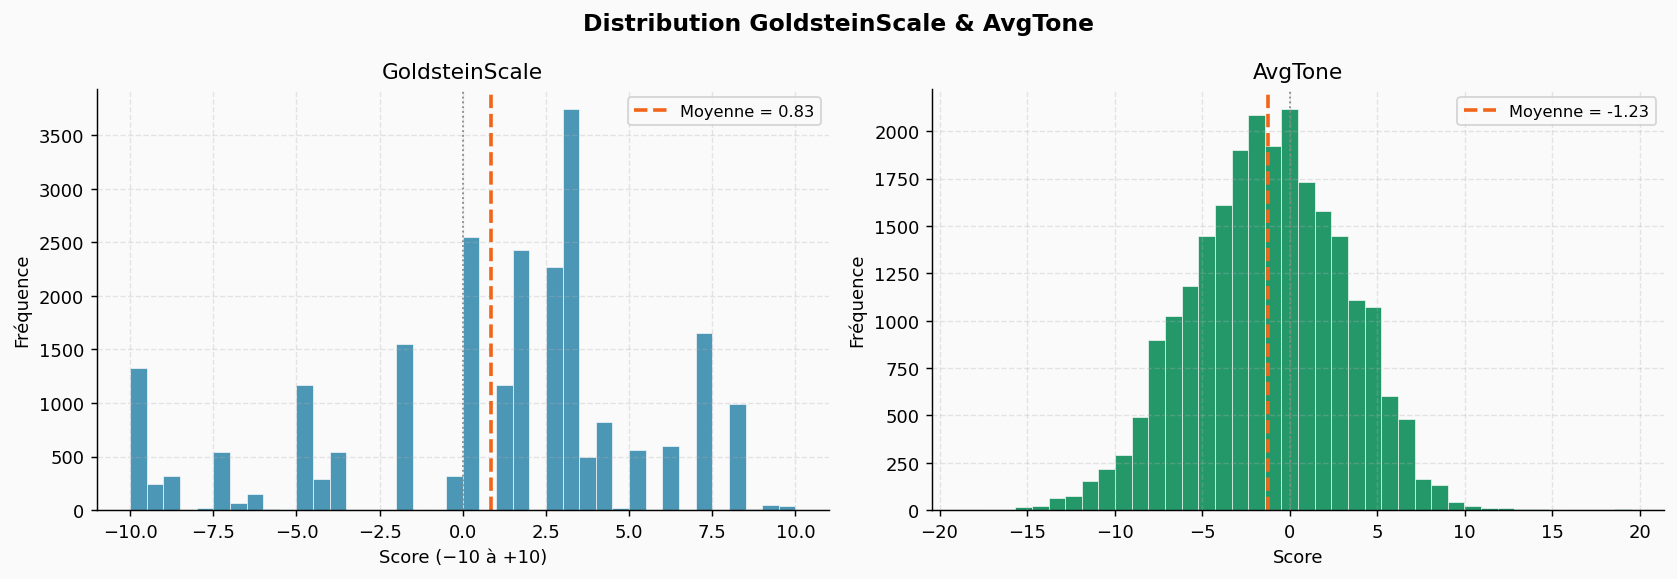

Figure sauvegardée : fig_distributions.png


In [23]:
# Distribution GoldsteinScale 
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Distribution GoldsteinScale & AvgTone', fontweight='bold', fontsize=13)

# GoldsteinScale
axes[0].hist(df['GoldsteinScale'].dropna(), bins=40,
             color=PALETTE['coop_verbal'], edgecolor='white',
             linewidth=0.4, alpha=0.85)
axes[0].axvline(df['GoldsteinScale'].mean(), color=PALETTE['conflict_material'],
                linewidth=2, linestyle='--',
                label=f"Moyenne = {df['GoldsteinScale'].mean():.2f}")
axes[0].axvline(0, color='#888', linewidth=1, linestyle=':')
axes[0].set_title('GoldsteinScale')
axes[0].set_xlabel('Score (−10 à +10)')
axes[0].set_ylabel('Fréquence')
axes[0].legend(fontsize=9)

# AvgTone
axes[1].hist(df['AvgTone'].dropna(), bins=40,
             color=PALETTE['benin_green'], edgecolor='white',
             linewidth=0.4, alpha=0.85)
axes[1].axvline(df['AvgTone'].mean(), color=PALETTE['conflict_material'],
                linewidth=2, linestyle='--',
                label=f"Moyenne = {df['AvgTone'].mean():.2f}")
axes[1].axvline(0, color='#888', linewidth=1, linestyle=':')
axes[1].set_title('AvgTone')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Fréquence')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_distributions.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_distributions.png")


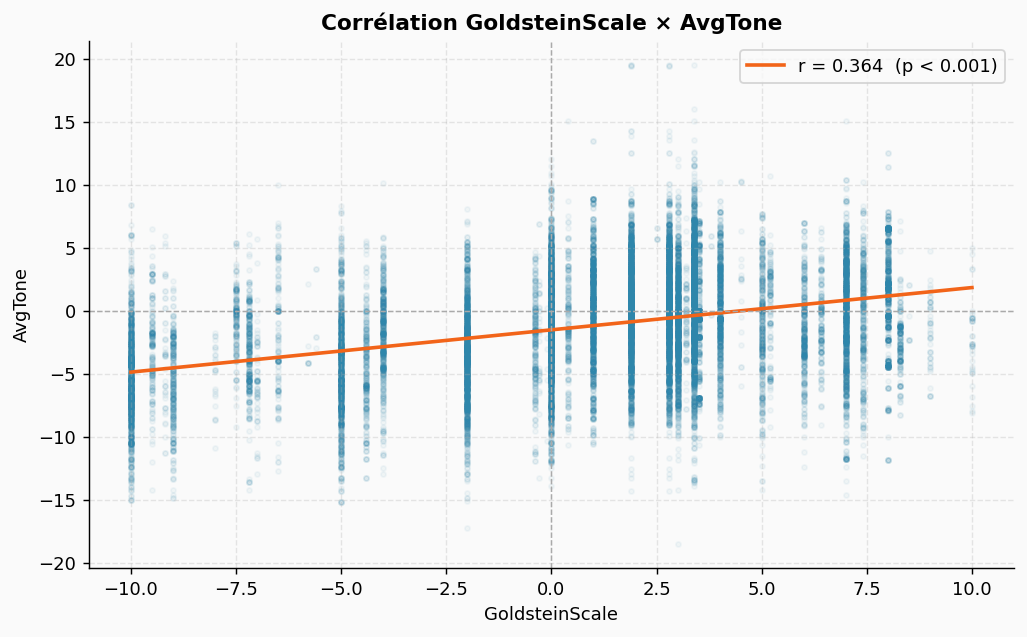

Corrélation de Pearson r = 0.364  (p = 0.00e+00)


In [24]:
# Corrélation GoldsteinScale vs AvgTone 
from scipy import stats as scipy_stats

r, p = scipy_stats.pearsonr(
    df['GoldsteinScale'].dropna(),
    df.loc[df['GoldsteinScale'].notna(), 'AvgTone']
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['GoldsteinScale'], df['AvgTone'],
           alpha=0.05, s=8, color=PALETTE['coop_verbal'])

# Droite de régression
m, b = np.polyfit(df['GoldsteinScale'].dropna(),
                  df.loc[df['GoldsteinScale'].notna(), 'AvgTone'], 1)
xs = np.linspace(-10, 10, 100)
ax.plot(xs, m*xs + b, color=PALETTE['conflict_material'],
        linewidth=2, label=f'r = {r:.3f}  (p < 0.001)')
ax.axhline(0, color='#aaa', linewidth=0.8, linestyle='--')
ax.axvline(0, color='#aaa', linewidth=0.8, linestyle='--')
ax.set_title('Corrélation GoldsteinScale × AvgTone', fontweight='bold')
ax.set_xlabel('GoldsteinScale')
ax.set_ylabel('AvgTone')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_corr.png', bbox_inches='tight', dpi=130)
plt.show()
print(f"Corrélation de Pearson r = {r:.3f}  (p = {p:.2e})")


## 9. Analyse des sources médiatiques <a id='8'></a>

Quelle est la géographie médiatique de la couverture du Bénin ?  
Quels médias dominent, et avec quel ton ?


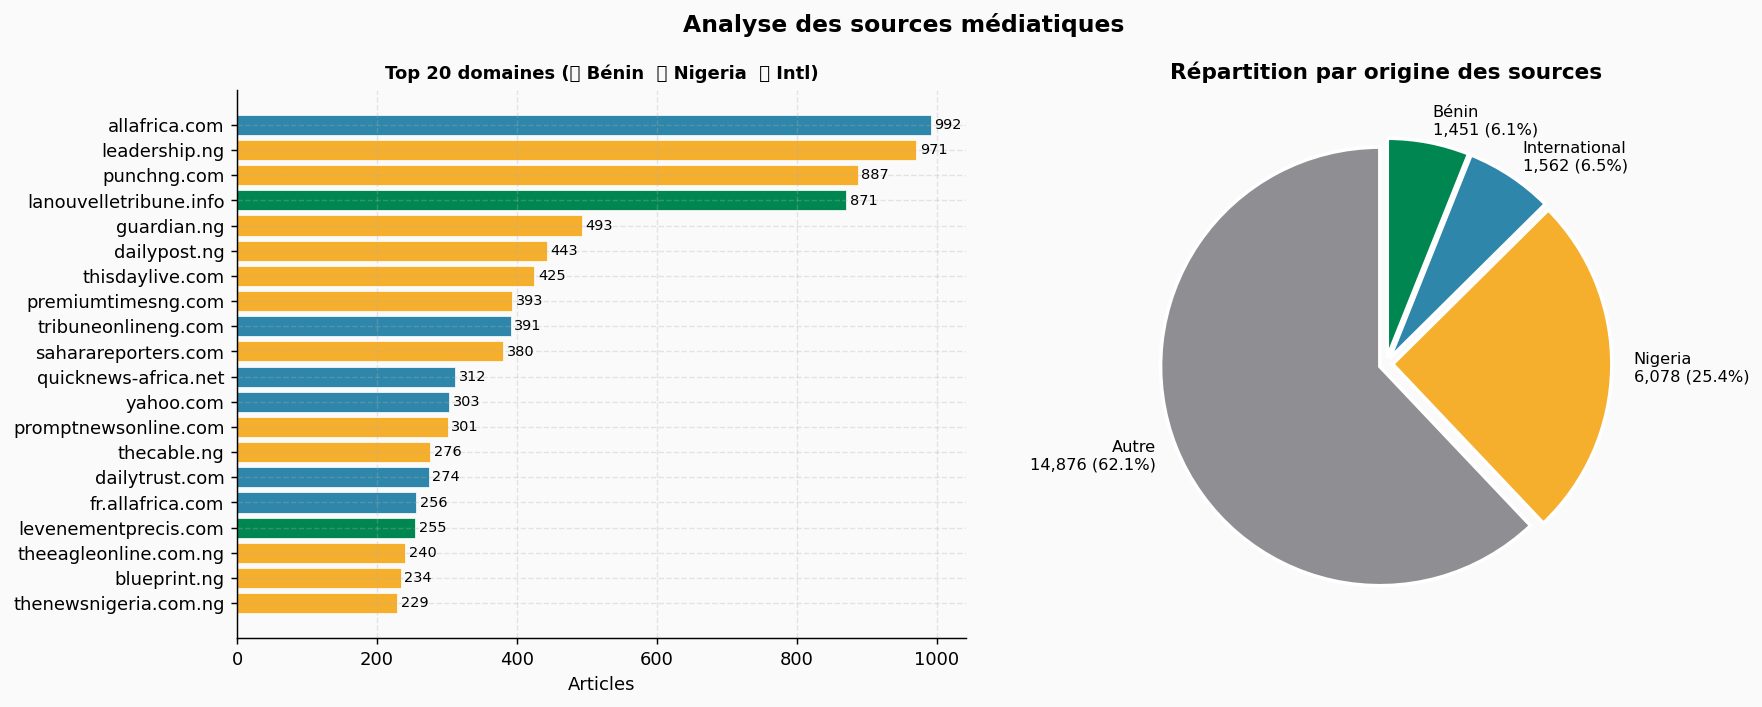

Figure sauvegardée : fig_sources.png


In [25]:
# Top 20 domaines sources 
top_domains = df['domain'].value_counts().head(20)

# Classifier manuellement les domaines par pays d'origine
BENIN_SOURCES    = {'lanouvelletribune.info','levenementprecis.com','24haubenin.info',
                    'beninnews.org','frinfo.org','gouv.bj','acotonou.com','beninwebtv.com',
                    'jeuneafrique.com'}  # (pan-africain basé à Paris mais couvre BJ)
NIGERIAN_SOURCES = {'punchng.com','dailypost.ng','leadership.ng','guardian.ng',
                    'thisdaylive.com','thenationonlineng.net','saharareporters.com',
                    'blueprint.ng','premiumtimesng.com','promptnewsonline.com'}
INTL_SOURCES     = {'allafrica.com','fr.allafrica.com','yahoo.com','reuters.com',
                    'apnews.com','rfi.fr','voaafrique.com'}

def classify_source(d):
    if d in BENIN_SOURCES: return 'Bénin'
    if d in NIGERIAN_SOURCES: return 'Nigeria'
    if d in INTL_SOURCES: return 'International'
    if str(d).endswith('.ng'): return 'Nigeria'
    if str(d).endswith('.bj'): return 'Bénin'
    return 'Autre'

df['source_origin'] = df['domain'].apply(classify_source)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Analyse des sources médiatiques', fontweight='bold', fontsize=13)

# Barres top domaines
colors_dom = [PALETTE['benin_green'] if classify_source(d) == 'Bénin'
              else PALETTE['conflict_verbal'] if classify_source(d) == 'Nigeria'
              else PALETTE['coop_verbal'] for d in top_domains.index]
bars = axes[0].barh(top_domains.index[::-1], top_domains.values[::-1],
                    color=colors_dom[::-1], edgecolor='white', linewidth=0.4)
for bar, val in zip(bars, top_domains.values[::-1]):
    axes[0].text(val + 5, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8)
axes[0].set_title('Top 20 domaines (🟢 Bénin  🟡 Nigeria  🔵 Intl)',
                  fontweight='bold', fontsize=10)
axes[0].set_xlabel('Articles')

# Camembert origine
origin_counts = df['source_origin'].value_counts()
origin_colors = {
    'Bénin': PALETTE['benin_green'], 'Nigeria': PALETTE['conflict_verbal'],
    'International': PALETTE['coop_verbal'], 'Autre': PALETTE['neutral']
}
axes[1].pie(
    origin_counts.values,
    labels=[f"{k}\n{v:,} ({100*v/len(df):.1f}%)" for k,v in origin_counts.items()],
    colors=[origin_colors.get(k, PALETTE['neutral']) for k in origin_counts.index],
    startangle=90, explode=[0.03]*len(origin_counts),
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize':9}
)
axes[1].set_title('Répartition par origine des sources', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_sources.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_sources.png")


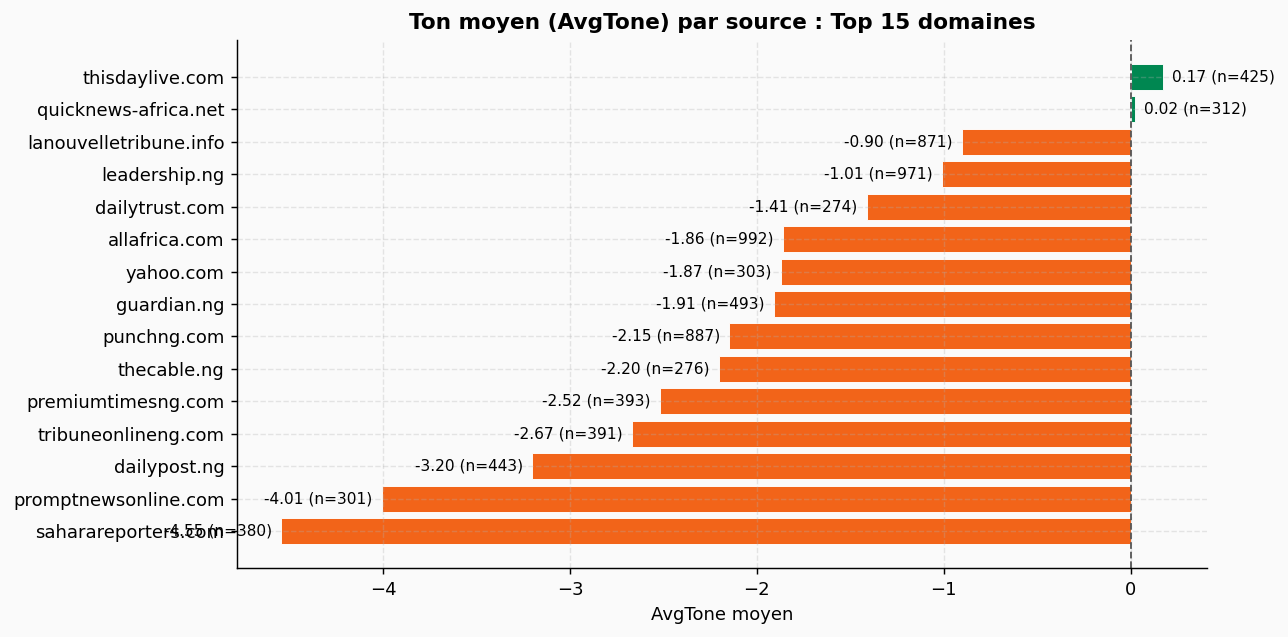

Figure sauvegardée : fig_tone_domain.png


In [26]:
# Ton moyen par domaine (top 15 sources)
top15 = df['domain'].value_counts().head(15).index
tone_by_domain = (df[df['domain'].isin(top15)]
                  .groupby('domain')['AvgTone']
                  .agg(['mean','count'])
                  .sort_values('mean'))

fig, ax = plt.subplots(figsize=(10, 5))
colors_tone = [PALETTE['conflict_material'] if t < 0 else PALETTE['benin_green']
               for t in tone_by_domain['mean']]
bars = ax.barh(tone_by_domain.index, tone_by_domain['mean'],
               color=colors_tone, edgecolor='white', linewidth=0.5)
for bar, (_, row) in zip(bars, tone_by_domain.iterrows()):
    x = row['mean']
    ax.text(x + (0.05 if x >= 0 else -0.05),
            bar.get_y() + bar.get_height()/2,
            f"{x:.2f} (n={int(row['count']):,})",
            va='center', ha='left' if x >= 0 else 'right', fontsize=8.5)
ax.axvline(0, color='#555', linewidth=1, linestyle='--')
ax.set_title('Ton moyen (AvgTone) par source : Top 15 domaines',
             fontweight='bold', fontsize=12)
ax.set_xlabel('AvgTone moyen')
plt.tight_layout()
plt.savefig('fig_tone_domain.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_tone_domain.png")


## 10. Synthèse & observations clés <a id='9'></a>


In [27]:
print("=" * 60)
print("  SYNTHÈSE EDA : GDELT BÉNIN 2025")
print("=" * 60)

n_coop     = df['QuadClass'].isin([1,2]).sum()
n_conflict = df['QuadClass'].isin([3,4]).sum()
gs_mean    = df['GoldsteinScale'].mean()
tone_mean  = df['AvgTone'].mean()
top_actor1 = df['Actor1Name'].value_counts().index[0]
top_actor2 = df['Actor2Name'].value_counts().index[0]
top_event  = df['EventRoot_label'].value_counts().index[0]
top_place  = df['ActionGeo_FullName'].value_counts().index[0]
top_domain = df['domain'].value_counts().index[0]

print(f"\n # Volume & couverture")
print(f"  {len(df):,} événements sur 12 mois (2025)")
print(f"  {df['domain'].nunique()} sources médiatiques distinctes")

print(f"\n #  Coopération vs Conflit")
print(f"  Coopération : {n_coop:,} ({100*n_coop/len(df):.1f}%)")
print(f"  Conflit     : {n_conflict:,} ({100*n_conflict/len(df):.1f}%)")
print(f"  → Le Bénin présente un profil majoritairement coopératif")

print(f"\n # Stabilité géopolitique")
print(f"  GoldsteinScale moyen : {gs_mean:.2f}  (légèrement positif → stable)")
print(f"  AvgTone moyen        : {tone_mean:.2f} (légèrement négatif → couverture prudente)")

print(f"\n # Acteurs dominants")
print(f"  Initiateur principal : {top_actor1}")
print(f"  Cible principale     : {top_actor2}")

print(f"\n # Événement le plus fréquent")
print(f"  {top_event} ({df['EventRoot_label'].value_counts().iloc[0]:,} occurrences)")

print(f"\n # Géographie")
print(f"  Lieu le plus cité : {top_place}")
print(f"  Partenaires régionaux clés : Nigeria, Togo, Niger, Ghana, Burkina Faso")

print(f"\n # Médias")
print(f"  Source dominante  : {top_domain}")
origin_dist = df['source_origin'].value_counts()
for orig, cnt in origin_dist.items():
    print(f"  {orig:<15} : {cnt:,} articles ({100*cnt/len(df):.1f}%)")

print("\n" + "=" * 60)


  SYNTHÈSE EDA : GDELT BÉNIN 2025

 # Volume & couverture
  23,967 événements sur 12 mois (2025)
  1460 sources médiatiques distinctes

 #  Coopération vs Conflit
  Coopération : 18,048 (75.3%)
  Conflit     : 5,919 (24.7%)
  → Le Bénin présente un profil majoritairement coopératif

 # Stabilité géopolitique
  GoldsteinScale moyen : 0.83  (légèrement positif → stable)
  AvgTone moyen        : -1.23 (légèrement négatif → couverture prudente)

 # Acteurs dominants
  Initiateur principal : BENIN
  Cible principale     : BENIN

 # Événement le plus fréquent
  Consult (6,476 occurrences)

 # Géographie
  Lieu le plus cité : Benin
  Partenaires régionaux clés : Nigeria, Togo, Niger, Ghana, Burkina Faso

 # Médias
  Source dominante  : allafrica.com
  Autre           : 14,876 articles (62.1%)
  Nigeria         : 6,078 articles (25.4%)
  International   : 1,562 articles (6.5%)
  Bénin           : 1,451 articles (6.1%)

